# Challenge 2 — Receipt Q&A

**Goal:** Build a five-tier OCR pipeline to extract structured entities (`company`, `date`, `address`, `total`) from scanned receipt images, then evaluate each tier on the SROIE V2 dataset (973 receipts).

## Pipeline Overview

```
Receipt Image
      ↓
Five-Tier Pipeline:
  Tier 1 — Raw EasyOCR                    (baseline, no LLM)
  Tier 2 — Gemini multimodal OCR          (vision LLM raw text)
  Tier 3 — EasyOCR  + Entity LLM         (OCR → LLM entity extraction)
  Tier 4 — Gemini OCR + Entity LLM       (vision OCR → LLM entity extraction)
  Tier 5 — Unified Multimodal LLM        (single Gemini call: image → entities)
      ↓
Structured entities → fuzzy-matched vs SROIE ground truth
```

**LLM corrections applied in Tiers 3, 4, 5:**
- OCR misreads (`0↔O`, `1↔l`, `rn↔m`)
- Broken compound business names (e.g. `MYDIN MO` → full legal name)
- Spacing, punctuation, and currency normalisation

**Dataset:** [SROIE V2](https://www.kaggle.com/datasets/urbikn/sroie-datasetv2) — 626 train + 347 test receipts with ground-truth annotations

## 1. Setup & Data Loading

Initialise EasyOCR (CPU or Apple MPS), set up paths for the SROIE train and test splits.

In [1]:
from pathlib import Path
import json
import torch
import easyocr
import matplotlib.pyplot as plt
from PIL import Image

import warnings

warnings.filterwarnings("ignore", message=".*pin_memory.*")

# Combined train + test paths
TRAIN_IMG_DIR = Path("../data/raw/SROIE2019/train/img")
TRAIN_ENTITIES_DIR = Path("../data/raw/SROIE2019/train/entities")
TEST_IMG_DIR = Path("../data/raw/SROIE2019/test/img")
TEST_ENTITIES_DIR = Path("../data/raw/SROIE2019/test/entities")

reader = easyocr.Reader(["en"], gpu=torch.backends.mps.is_available())
print(f"MPS: {torch.backends.mps.is_available()}")

MPS: True


## 2. Tier 1 — Raw EasyOCR Baseline

Run EasyOCR on a sample receipt, visualise bounding-box detections, and compare the raw extracted text against the ground-truth entity annotations. Boxes in **green** pass the confidence threshold (≥ 0.2); **red** boxes are below threshold and filtered out.

> Confidence threshold of 0.2 was selected empirically — higher values discard genuine entity text on low-quality scans.

In [2]:
def run_ocr(image_path: Path, confidence_threshold: float = 0.2) -> dict:
    detections = reader.readtext(str(image_path))
    filtered = [
        (bbox, text, conf)
        for bbox, text, conf in detections
        if conf >= confidence_threshold
    ]
    return {
        "raw_text": "\n".join([text for _, text, _ in filtered]),
        "detections": detections,
        "confidences": [conf for _, _, conf in detections],
    }

In [3]:
sample_img = next(TRAIN_IMG_DIR.glob("X00016469612.jpg"))
ocr_output = run_ocr(sample_img)

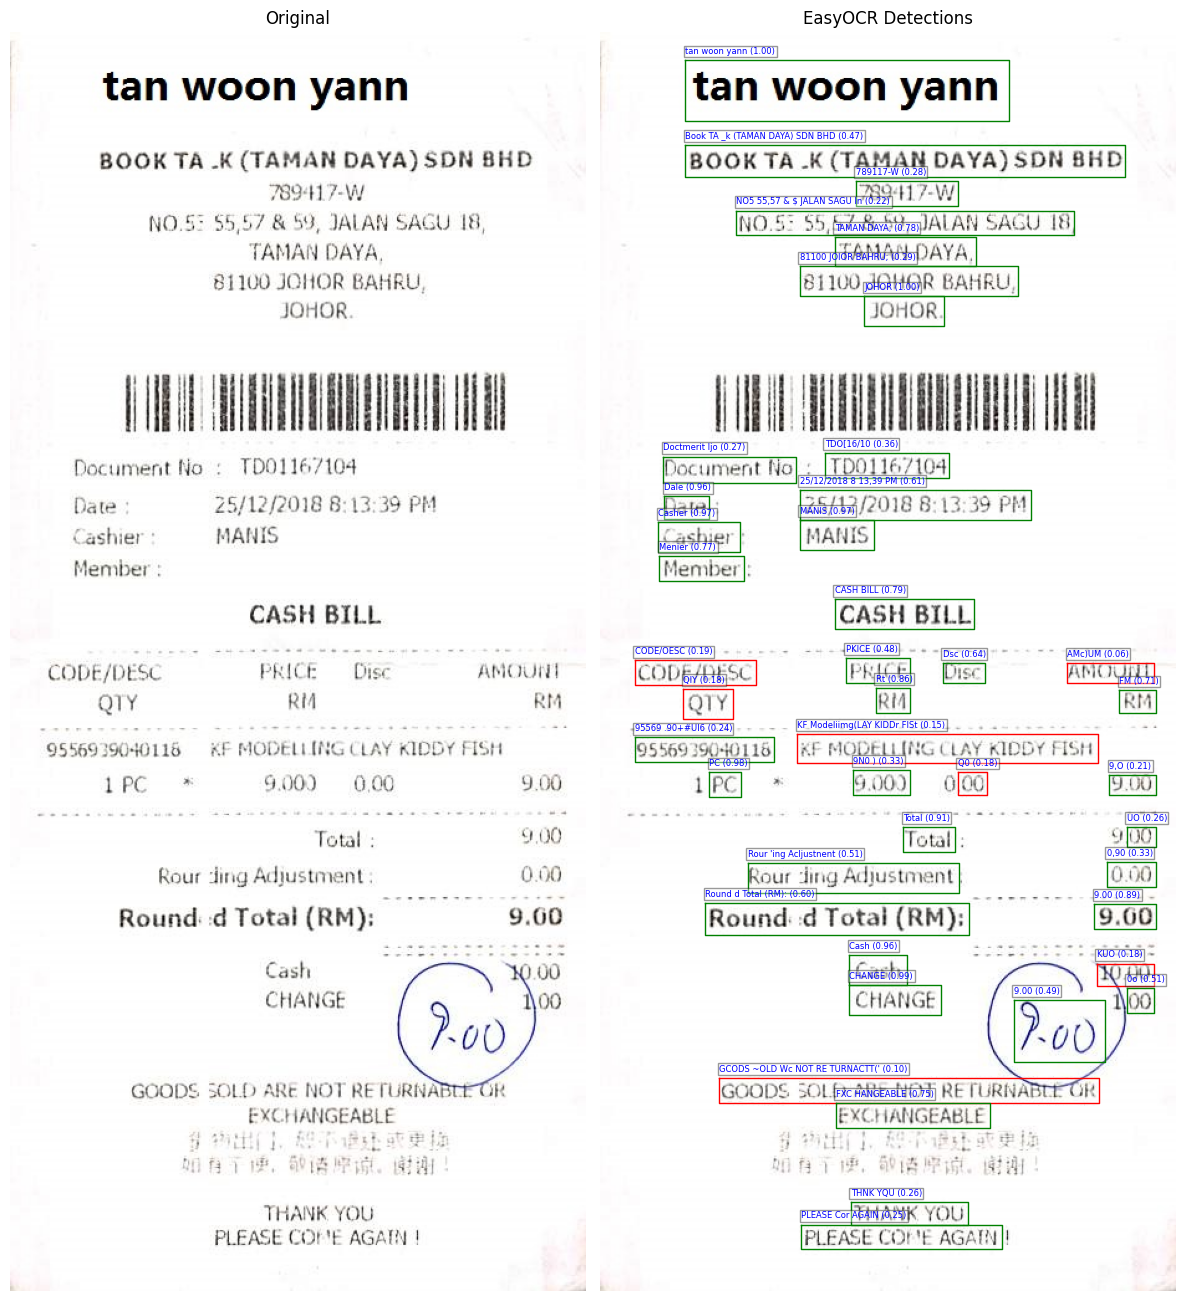

In [4]:
def visualize_ocr(image_path: Path, ocr_output: dict, figsize=(12, 14)):
    img = Image.open(image_path)
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    axes[0].imshow(img)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(img)
    axes[1].set_title("EasyOCR Detections")
    axes[1].axis("off")

    for bbox, text, conf in ocr_output["detections"]:
        xs = [p[0] for p in bbox] + [bbox[0][0]]
        ys = [p[1] for p in bbox] + [bbox[0][1]]
        color = "green" if conf >= 0.2 else "red"
        axes[1].plot(xs, ys, "-", color=color, linewidth=1)
        axes[1].text(
            bbox[0][0],
            bbox[0][1] - 5,
            f"{text} ({conf:.2f})",
            color="blue",
            fontsize=6,
            bbox=dict(facecolor="white", alpha=0.4, pad=1),
        )

    plt.tight_layout()
    plt.show()


visualize_ocr(sample_img, ocr_output)

In [5]:
def load_gt(entities_dir: Path, image_path: Path) -> dict:
    gt_path = entities_dir / image_path.with_suffix(".txt").name
    return json.loads(gt_path.read_text())

In [6]:
all_pairs = [
    (img, TRAIN_ENTITIES_DIR / img.with_suffix(".txt").name)
    for img in sorted(TRAIN_IMG_DIR.glob("*.jpg"))
] + [
    (img, TEST_ENTITIES_DIR / img.with_suffix(".txt").name)
    for img in sorted(TEST_IMG_DIR.glob("*.jpg"))
]

print(f"Total receipts: {len(all_pairs)}")

Total receipts: 973


In [7]:
gt = load_gt(TRAIN_ENTITIES_DIR, sample_img)

print(f"FILE: {sample_img.name}")
print(f"OCR:\n  " + ocr_output["raw_text"].replace("\n", "\n  "))
print("GT:")
for k, v in gt.items():
    print(f"  {k}: {v}")

FILE: X00016469612.jpg
OCR:
  tan woon yann
  Book TA _k (TAMAN DAYA) SDN BHD
  789117-W
  NO5 55,57 & $ JALAN SAGU In
  TAMAN DAYA;
  81100 JOlOR BAHRU;
  JOHOR
  Doctmerit Ijo
  TDO[16/10
  Dale
  25/12/2018 8 13,39 PM
  Casher
  MANIS
  Menier
  CASH BILL
  PKICE
  Dsc
  Rt
  FM
  95569 .90+#UI6
  PC
  9N0 )
  9,O
  Total
  UO
  Rour 'ing Acljustnent
  0,90
  Round d Total (RM):
  9.00
  Cash
  CHANGE
  0o
  9.00
  FXC HANGEABLE
  THNK YQU
  PLEASE Cor AGAIN
GT:
  company: BOOK TA .K (TAMAN DAYA) SDN BHD
  date: 25/12/2018
  address: NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 81100 JOHOR BAHRU, JOHOR.
  total: 9.00


## 3. Tier 2 — Gemini Multimodal OCR

Replace EasyOCR with a direct vision-language call to **Gemini 2.5 Flash**: the raw receipt image is sent as base64 and the model is prompted to transcribe all visible text verbatim. No entity extraction yet — this is a pure OCR quality comparison against Tier 1.

In [9]:
import os
import base64
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.messages import HumanMessage

load_dotenv()

model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [10]:
def encode_image(image_path: Path) -> str:
    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

In [39]:
def improved_ocr(image_path: Path) -> str:
    encoded = encode_image(image_path)
    message = HumanMessage(
        content=[
            {
                "type": "text",
                "text": "Extract all text you see in this receipt image exactly as it appears. Preserve the original content and structure.",
            },
            {"type": "image", "base64": encoded, "mime_type": "image/jpeg"},
        ]
    )
    result = model.invoke([message]).content
    if isinstance(result, list):
        return " ".join(
            part["text"] if isinstance(part, dict) else str(part) for part in result
        )
    return result


# Test on sample
result = improved_ocr(sample_img)
print(f"FILE: {sample_img.name}")
print(f"OCR:\n  " + result.replace("\n", "\n  "))
print("GT:")
for k, v in gt.items():
    print(f"  {k}: {v}")

FILE: X00016469612.jpg
OCR:
  tan woon yann
  
  BOOK TA JK (TAMAN DAYA) SDN BHD
  789417-W
  NO.53 55,57 & 59, JALAN SAGU 18,
  TAMAN DAYA,
  81100 JOHOR BAHRU,
  JOHOR.
  
  Document No : TD01167104
  Date : 25/12/2018 8:13:39 PM
  Cashier : MANIS
  Member :
  
  CASH BILL
  
  CODE/DESC    PRICE Disc AMOUNT
  QTY          RM           RM
  9556939040118 KF MODELLING CLAY KIDDY FISH
  1 PC *       9.000 0.00       9.00
               Total :          9.00
  Rour ding Adjustment :        0.00
  Round d Total (RM):         9.00
  
  Cash                      10.00
  CHANGE                      1.00
  (9-00)
  
  GOODS SOLD ARE NOT RETURNABLE OR
  EXCHANGEABLE
  貨物出門,恕不退还或更换
  如有不便,敬请谅解.谢谢!
  
  THANK YOU
  PLEASE COME AGAIN!
GT:
  company: HON HWA HARDWARE TRADING
  date: 21/09/2017
  address: NO 37, JALAN MANIS 7, TAMAN SEGAR, 56100 CHERAS, KUALA LUMPUR.
  total: 10.40


## 4. Tiers 3 & 4 — Entity Extraction LLM

Pass the raw OCR text (Tier 3: EasyOCR, Tier 4: Gemini OCR) through a Gemini LLM with structured output (`ReceiptEntities`) to extract the four target fields. The LLM corrects OCR artefacts and completes partial entities using world knowledge.

In [12]:
from pydantic import BaseModel, Field
from typing import Optional


class ReceiptEntities(BaseModel):
    company: Optional[str] = Field(None, description="Business or vendor name")
    date: Optional[str] = Field(
        None, description="Transaction date only, no time or timezone"
    )
    address: Optional[str] = Field(None, description="Business address")
    total: Optional[str] = Field(None, description="Final total amount")

In [13]:
entity_llm = model.with_structured_output(ReceiptEntities)


def extract_entities(text: str) -> ReceiptEntities:
    prompt = f"""You are analyzing OCR text from a scanned receipt.
Extract the required entities and in doing so:

1. Rectify malformed words caused by OCR misreads:
   - Character confusion (e.g. '0' misread as 'O', '1' as 'l', 'rn' as 'm')
   - Broken words (e.g. 'To tal' should be 'Total')
   - Garbled text (e.g. 'sollor' should be 'seller')

2. Complete compound entities with missing components:
   - Use world knowledge to complete partial business names
     (e.g. 'MYDIN MO' should be completed to 'MYDIN MOHAMED HOLDINGS SDN BHD')
   - Complete partial addresses using surrounding context clues

3. Apply any other necessary corrections:
   - Normalize spacing and punctuation where clearly wrong
   - Fix split lines that belong together
   - Correct currency symbols or amount formatting if malformed

Important:
- Do not add information that cannot be inferred from the text or world knowledge

Receipt OCR text:
{text}"""

    return entity_llm.invoke([HumanMessage(content=prompt)])


# Test Tier 3 — entity LLM from EasyOCR text
easy_text = run_ocr(sample_img)["raw_text"]
entities = extract_entities(easy_text)
gt = load_gt(TRAIN_ENTITIES_DIR, sample_img)

print(f"FILE: {sample_img.name}")
print("ENTITIES:")
for k, v in entities.model_dump().items():
    print(f"  {k}: {v}")
print("GT:")
for k, v in gt.items():
    print(f"  {k}: {v}")

FILE: X00016469612.jpg
ENTITIES:
  company: Book Talk (TAMAN DAYA) SDN BHD
  date: 25/12/2018
  address: NO 55, 57 & 59 JALAN SAGU 1, TAMAN DAYA, 81100 JOHOR BAHRU, JOHOR
  total: 9.00
GT:
  company: BOOK TA .K (TAMAN DAYA) SDN BHD
  date: 25/12/2018
  address: NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 81100 JOHOR BAHRU, JOHOR.
  total: 9.00


## 5. Tier 5 — Unified Multimodal LLM

Collapse the two-step OCR + extraction pipeline into a **single Gemini call**: the image is sent directly alongside the entity-extraction prompt.

In [14]:
def unified_pipeline(image_path: Path) -> ReceiptEntities:
    encoded = encode_image(image_path)
    prompt = """You are processing a scanned receipt image.
Extract the required entities directly from the image and in doing so:

1. Rectify malformed words caused by OCR misreads:
   - Character confusion (e.g. '0' misread as 'O', '1' as 'l', 'rn' as 'm')
   - Broken words (e.g. 'To tal' should be 'Total')
   - Garbled text (e.g. 'sollor' should be 'seller')

2. Complete compound entities with missing components:
   - Use world knowledge to complete partial business names
     (e.g. 'MYDIN MO' should be completed to 'MYDIN MOHAMED HOLDINGS SDN BHD')
   - Complete partial addresses using surrounding context clues
     (e.g. a postcode or city name can help infer the full address)

3. Apply any other necessary corrections:
   - Normalize spacing and punctuation where clearly wrong
   - Fix split lines that belong together
   - Correct currency symbols or amount formatting if malformed

Important:
- Do not add information that cannot be inferred from the image or world knowledge
- Extract only what is present or reasonably inferable from the receipt"""

    message = HumanMessage(
        content=[
            {"type": "text", "text": prompt},
            {"type": "image", "base64": encoded, "mime_type": "image/jpeg"},
        ]
    )
    return entity_llm.invoke([message])


# Test unified pipeline
entities = unified_pipeline(sample_img)
gt = load_gt(TRAIN_ENTITIES_DIR, sample_img)

print(f"FILE: {sample_img.name}")
print("ENTITIES:")
for k, v in entities.model_dump().items():
    print(f"  {k}: {v}")
print("GT:")
for k, v in gt.items():
    print(f"  {k}: {v}")

FILE: X00016469612.jpg
ENTITIES:
  company: BOOK TALK (TAMAN DAYA) SDN BHD
  date: 25/12/2018
  address: NO.55 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 81100 JOHOR BAHRU, JOHOR
  total: 9.00
GT:
  company: BOOK TA .K (TAMAN DAYA) SDN BHD
  date: 25/12/2018
  address: NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 81100 JOHOR BAHRU, JOHOR.
  total: 9.00


## 6. Evaluation Framework

Two scoring functions compare pipeline output against SROIE ground truth using **RapidFuzz** fuzzy matching:

| Function | Used for | Match criterion |
|---|---|---|
| `evaluate_text_tier` | Tiers 1 & 2 (raw text) | `partial_ratio ≥ 30` — GT value appears somewhere in the OCR text |
| `evaluate_entity_tier` | Tiers 3, 4, 5 (structured) | `token_sort_ratio` on the extracted field value vs GT |

The single-sample comparison below validates all five tiers on one receipt before running the full dataset.

In [15]:
from rapidfuzz import fuzz


def evaluate_text_tier(raw_text, gt):
    results = {}
    for field, gt_value in gt.items():
        score = fuzz.partial_ratio(gt_value.lower(), raw_text.lower())
        results[field] = {"extracted": score >= 30, "score": score}
    return results


def evaluate_entity_tier(entities, gt):
    results = {}
    for field, gt_value in gt.items():
        pred = entities.get(field)
        results[field] = {
            "extracted": pred is not None,
            "score": (
                fuzz.token_sort_ratio(gt_value.lower(), pred.lower()) if pred else 0
            ),
        }
    return results

In [16]:
easy_text = ocr_output["raw_text"]
gemini_text = improved_ocr(sample_img)

tier1 = evaluate_text_tier(easy_text, gt)
tier2 = evaluate_text_tier(gemini_text, gt)
tier3 = evaluate_entity_tier(extract_entities(easy_text).model_dump(), gt)
tier4 = evaluate_entity_tier(extract_entities(gemini_text).model_dump(), gt)
tier5 = evaluate_entity_tier(unified_pipeline(sample_img).model_dump(), gt)

In [17]:
tiers = [tier1, tier2, tier3, tier4, tier5]
labels = [
    "T1 (EasyOCR)",
    "T2 (Gemini OCR)",
    "T3 (EasyOCR+LLM)",
    "T4 (Gemini+LLM)",
    "T5 (Unified)",
]
fields = ["company", "date", "address", "total"]

col_w = 20
print(f"FILE: {sample_img.name}\n")
print(f"  {'field':10}" + "".join(f"{l:>{col_w}}" for l in labels))
print(f"  {'-'*10}" + "-" * (col_w * len(labels)))
for field in fields:
    scores = [
        f"{'✓' if t[field]['extracted'] else '✗'} {t[field]['score']:.1f}"
        for t in tiers
    ]
    print(f"  {field:10}" + "".join(f"{s:>{col_w}}" for s in scores))

FILE: X00016469612.jpg

  field             T1 (EasyOCR)     T2 (Gemini OCR)    T3 (EasyOCR+LLM)     T4 (Gemini+LLM)        T5 (Unified)
  --------------------------------------------------------------------------------------------------------------
  company                 ✓ 96.8              ✓ 96.8              ✓ 93.3              ✓ 93.3              ✓ 91.8
  date                   ✓ 100.0             ✓ 100.0             ✓ 100.0             ✓ 100.0             ✓ 100.0
  address                 ✓ 78.6              ✓ 95.7              ✓ 94.9             ✓ 100.0              ✓ 97.1
  total                  ✓ 100.0             ✓ 100.0             ✓ 100.0             ✓ 100.0             ✓ 100.0


## 7. Full Dataset Evaluation

Run all five tiers across all 973 receipts (626 train + 347 test). Progress is **checkpointed** to `data/processed/results_checkpoint.json` every 10 receipts so the run can be resumed if interrupted — each receipt requires up to 4 Gemini API calls (Tiers 2, 3, 4, 5).

In [40]:
from tqdm import tqdm

CHECKPOINT_PATH = Path("../data/processed/results_checkpoint.json")


def save_checkpoint(results: dict):
    CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(CHECKPOINT_PATH, "w") as f:
        json.dump(results, f)


def load_checkpoint() -> dict:
    if CHECKPOINT_PATH.exists():
        with open(CHECKPOINT_PATH) as f:
            return json.load(f)
    return {}


# Load existing checkpoint if available
checkpoint = load_checkpoint()
tier1_results = checkpoint.get("tier1", [])
tier2_results = checkpoint.get("tier2", [])
tier3_results = checkpoint.get("tier3", [])
tier4_results = checkpoint.get("tier4", [])
tier5_results = checkpoint.get("tier5", [])

# Resume from where we left off
start_idx = len(tier1_results)
print(f"Resuming from index {start_idx}/{len(all_pairs)}")

for img_path, gt_path in tqdm(all_pairs[start_idx:]):
    gt = json.loads(gt_path.read_text())
    easy_text = run_ocr(img_path)["raw_text"]
    gemini_text = improved_ocr(img_path)
    entities_t3 = extract_entities(easy_text).model_dump()
    entities_t4 = extract_entities(gemini_text).model_dump()
    entities_t5 = unified_pipeline(img_path).model_dump()

    tier1_results.append(evaluate_text_tier(easy_text, gt))
    tier2_results.append(evaluate_text_tier(gemini_text, gt))
    tier3_results.append(evaluate_entity_tier(entities_t3, gt))
    tier4_results.append(evaluate_entity_tier(entities_t4, gt))
    tier5_results.append(evaluate_entity_tier(entities_t5, gt))

    # Save checkpoint every 10 receipts
    if len(tier1_results) % 10 == 0:
        save_checkpoint(
            {
                "tier1": tier1_results,
                "tier2": tier2_results,
                "tier3": tier3_results,
                "tier4": tier4_results,
                "tier5": tier5_results,
            }
        )

# Final save
save_checkpoint(
    {
        "tier1": tier1_results,
        "tier2": tier2_results,
        "tier3": tier3_results,
        "tier4": tier4_results,
        "tier5": tier5_results,
    }
)

print("Done")

Resuming from index 300/973


100%|██████████| 673/673 [5:03:15<00:00, 27.04s/it]    

Done


## 8. Results Aggregation & Analysis

Aggregate per-field extraction rates and average fuzzy-match scores across all receipts for each tier. Results are split into two tables:
- **OCR Quality** (Tiers 1 & 2): how well the raw text contains the ground-truth values
- **Extraction Quality** (Tiers 3, 4, 5): how accurately structured entities are recovered

In [41]:
def aggregate_results(all_results):
    fields = ["company", "date", "address", "total"]
    n = len(all_results)
    summary = {}

    for field in fields:
        field_results = [r for r in all_results if field in r]
        summary[field] = {
            "extraction_rate": sum(r[field]["extracted"] for r in field_results)
            / len(field_results),
            "avg_score": sum(r[field]["score"] for r in field_results)
            / len(field_results),
        }

    summary["overall"] = {
        "extraction_rate": sum(summary[f]["extraction_rate"] for f in fields)
        / len(fields),
        "avg_score": sum(summary[f]["avg_score"] for f in fields) / len(fields),
    }

    return summary

In [42]:
summary = {
    "Tier 1 - Raw OCR": aggregate_results(tier1_results),
    "Tier 2 - Improved OCR": aggregate_results(tier2_results),
    "Tier 3 - Raw OCR + Entity LLM": aggregate_results(tier3_results),
    "Tier 4 - Improved OCR + Entity LLM": aggregate_results(tier4_results),
    "Tier 5 - Unified Multimodal LLM": aggregate_results(tier5_results),
}

In [43]:
fields = ["company", "date", "address", "total", "overall"]

# OCR Quality Table (Tiers 1 & 2)
print("=== OCR Quality (Tiers 1 & 2) ===")
print(f"{'field':10} {'T1 ext':>8} {'T1 score':>10} {'T2 ext':>8} {'T2 score':>10}")
print("-" * 50)
for field in fields:
    t1 = summary["Tier 1 - Raw OCR"][field]
    t2 = summary["Tier 2 - Improved OCR"][field]
    print(
        f"{field:10} "
        f"{t1['extraction_rate']:>8.1%} "
        f"{t1['avg_score']:>10.1f} "
        f"{t2['extraction_rate']:>8.1%} "
        f"{t2['avg_score']:>10.1f}"
    )

# Extraction Quality Table (Tiers 3, 4 & 5)
print("\n=== Extraction Quality (Tiers 3, 4 & 5) ===")
print(
    f"{'field':10} {'T3 ext':>8} {'T3 score':>10} {'T4 ext':>8} {'T4 score':>10} {'T5 ext':>8} {'T5 score':>10}"
)
print("-" * 70)
for field in fields:
    t3 = summary["Tier 3 - Raw OCR + Entity LLM"][field]
    t4 = summary["Tier 4 - Improved OCR + Entity LLM"][field]
    t5 = summary["Tier 5 - Unified Multimodal LLM"][field]
    print(
        f"{field:10} "
        f"{t3['extraction_rate']:>8.1%} "
        f"{t3['avg_score']:>10.1f} "
        f"{t4['extraction_rate']:>8.1%} "
        f"{t4['avg_score']:>10.1f} "
        f"{t5['extraction_rate']:>8.1%} "
        f"{t5['avg_score']:>10.1f}"
    )

=== OCR Quality (Tiers 1 & 2) ===
field        T1 ext   T1 score   T2 ext   T2 score
--------------------------------------------------
company      100.0%       88.7    99.3%       98.7
date         100.0%       95.1    99.4%       98.6
address       99.9%       84.6    99.3%       95.9
total         99.9%       89.5    99.1%       98.6
overall       99.9%       89.5    99.3%       97.9

=== Extraction Quality (Tiers 3, 4 & 5) ===
field        T3 ext   T3 score   T4 ext   T4 score   T5 ext   T5 score
----------------------------------------------------------------------
company       97.6%       85.4    99.3%       92.9   100.0%       95.0
date          96.8%       94.3    98.6%       97.5   100.0%       98.3
address       99.6%       87.1    99.3%       94.4   100.0%       94.7
total         99.7%       95.0    98.5%       96.1   100.0%       97.5
overall       98.4%       90.5    98.9%       95.2   100.0%       96.4
